# 🧠 MathsMate — Cognitive Skill Profile
## Decision Tree Multi-Output Classification Model

---

### 📌 Project Overview

**MathsMate** is an AI-powered adaptive math learning platform designed for students who struggle with mathematics, including students with dyscalculia. This notebook trains a **Cognitive Skill Profiling Model** that analyses student interaction data and predicts a multi-dimensional cognitive profile for each learner.

### 🎯 Objective

Given a student's interaction log for a math question (response time, attempts, correctness, hint usage, etc.), predict **four cognitive skill labels simultaneously**:

| Target Label | Classes | Meaning |
|---|---|---|
| `label_memory` | Low / Medium / High | Working memory capacity |
| `label_attention` | Low / Medium / High | Sustained attention & focus |
| `label_number_sense` | Low / Medium / High | Intuitive understanding of numbers |
| `label_processing_speed` | Slow / Moderate / Fast | Speed of information processing |

### 🔬 Why Multi-Output Classification?

This is a **Multi-Output Classification** problem because:
- We are predicting **more than one target label** at the same time from the same input features.
- Each target is a **categorical/class label** (not a number), so it is classification, not regression.
- The four cognitive dimensions are **partially correlated** but each has its own independent prediction.
- A single model trained with `MultiOutputClassifier` is more efficient than training four separate models.

### 🌳 Why Decision Tree?

- Decision Trees are **interpretable** — we can explain why a prediction was made.
- Suitable for **educational research** where transparency matters.
- Handles both **numerical and categorical** features well.
- Easy to visualise and explain to non-technical stakeholders (teachers, parents, researchers).
- Appropriate for this **dataset size** (small pilot dataset, ~1120 rows, 63 students).


## 1️⃣ Import Libraries

In [57]:
# Standard libraries
import warnings
import os
import json

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn — model
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    hamming_loss
)

# Scikit-learn — model selection
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV

# Model persistence
import joblib

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
import sklearn; print(f"   sklearn : {sklearn.__version__}")


✅ All libraries imported successfully.
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : 1.6.1


## 2️⃣ Load Dataset

The dataset `cognitive_data_master.csv` contains student-question interaction logs from MathsMate.
Each **row = one question answered by one student**.


In [58]:
# ── File path (update if running from a different directory) ──
DATA_FILE = 'cognitive_data_master.csv'

# ── Fallback check ──────────────────────────────────────────
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Dataset not found: '{DATA_FILE}'\n"
        "Please place the CSV file in the same folder as this notebook."
    )

# ── Load ────────────────────────────────────────────────────
df = pd.read_csv(DATA_FILE)

print(f"✅ Dataset loaded:  {DATA_FILE}")
print(f"   Shape          :  {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Unique students:  {df['student_id'].nunique()}")
print(f"   Unique questions: {df['question_id'].nunique()}")


✅ Dataset loaded:  cognitive_data_master.csv
   Shape          :  1120 rows × 16 columns
   Unique students:  63
   Unique questions: 20


In [59]:
# First 5 rows
print("── First 5 rows ──")
df.head()


── First 5 rows ──


,student_id,question_id,topic,difficulty,response_time_sec,attempts,is_correct,hint_used,click_count,session_time_sec,time_between_actions,error_type,label_memory,label_attention,label_number_sense,label_processing_speed
0,S001,Q001,Counting,Easy,2.8,1,True,False,4,47.0,0.4,none,Medium,High,High,Moderate
1,S001,Q002,Addition,Easy,10.9,1,True,False,1,67.5,5.1,none,Medium,High,High,Moderate
2,S001,Q003,Number Comparison,Easy,11.7,1,True,False,2,87.6,3.5,none,Medium,High,High,Moderate
3,S001,Q004,Subtraction,Easy,10.3,1,True,False,4,104.0,1.7,none,Medium,High,High,Moderate
4,S001,Q005,Counting,Easy,8.4,1,True,False,4,119.9,1.6,none,Medium,High,High,Moderate


In [60]:
# Column names and data types
print("── Column Names ──")
print(df.columns.tolist())
print()
print("── Data Types & Non-Null Counts ──")
df.info()


── Column Names ──
['student_id', 'question_id', 'topic', 'difficulty', 'response_time_sec', 'attempts', 'is_correct', 'hint_used', 'click_count', 'session_time_sec', 'time_between_actions', 'error_type', 'label_memory', 'label_attention', 'label_number_sense', 'label_processing_speed']

── Data Types & Non-Null Counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1120 entries, 0 to 1119
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              1120 non-null   object 
 1   question_id             1120 non-null   object 
 2   topic                   1120 non-null   object 
 3   difficulty              1120 non-null   object 
 4   response_time_sec       1120 non-null   float64
 5   attempts                1120 non-null   int64  
 6   is_correct              1120 non-null   bool   
 7   hint_used               1120 non-null   bool   
 8   click_count             1120 non-n

## 3️⃣ Basic Dataset Understanding

Before building the model, we explore the data to understand its structure, distributions, and patterns.


In [61]:
# ── Student & Question counts ──────────────────────────────
print(f"Students  : {df['student_id'].nunique()}")
print(f"Questions : {df['question_id'].nunique()}")
print(f"Total rows: {len(df)}")
print(f"Max possible rows (63×20): 1260")
print(f"Completion rate: {len(df)/1260*100:.1f}%")

# ── Topic distribution ──────────────────────────────────────
print("\n── Topic Distribution ──")
print(df['topic'].value_counts())

# ── Difficulty distribution ─────────────────────────────────
print("\n── Difficulty Distribution ──")
print(df['difficulty'].value_counts())


Students  : 63
Questions : 20
Total rows: 1120
Max possible rows (63×20): 1260
Completion rate: 88.9%

── Topic Distribution ──
topic
Addition             297
Subtraction          286
Number Comparison    277
Counting             260
Name: count, dtype: int64

── Difficulty Distribution ──
difficulty
Medium    489
Hard      316
Easy      315
Name: count, dtype: int64


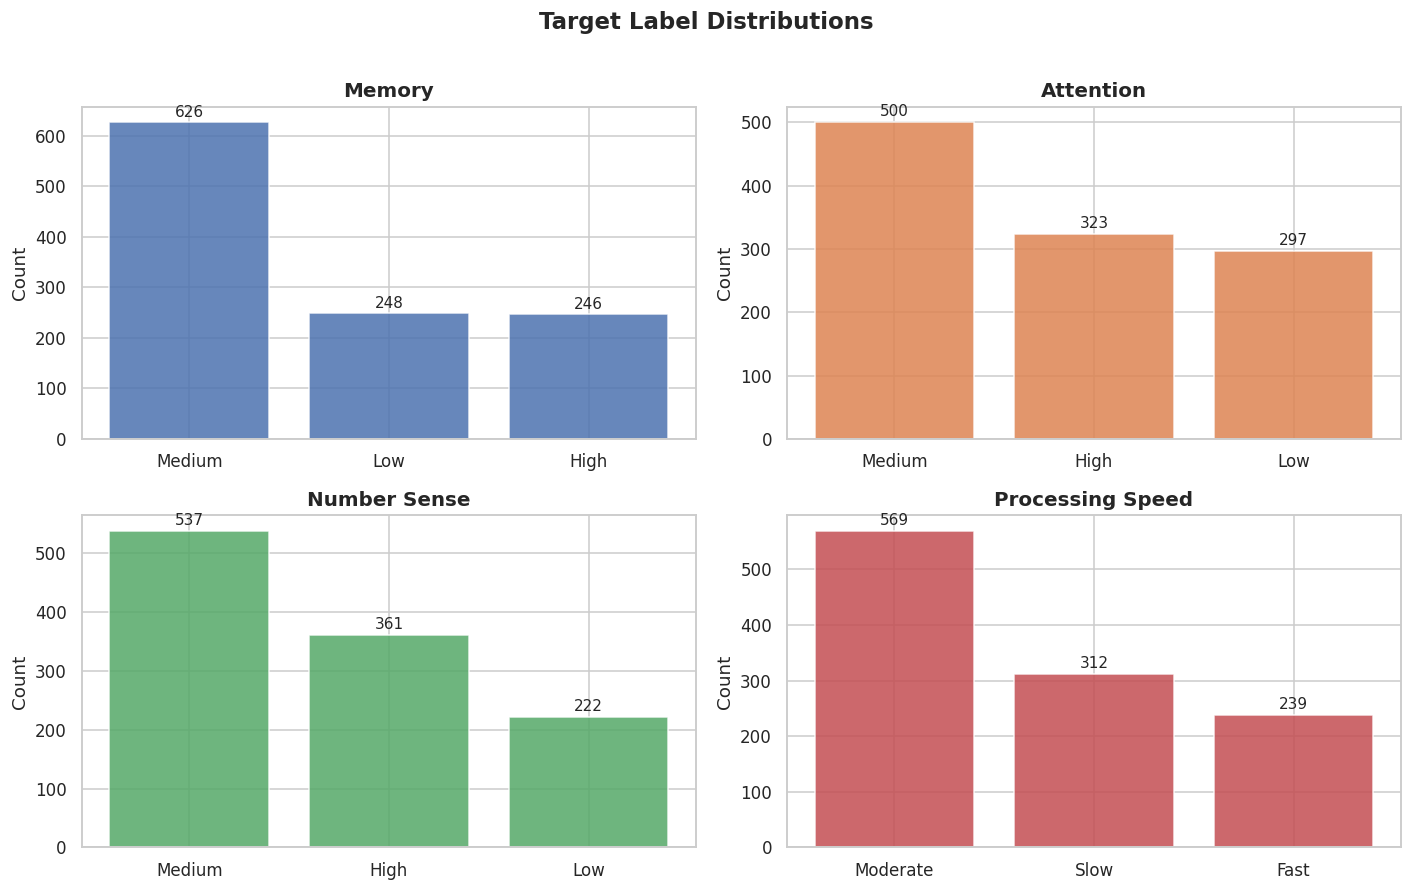

✅ Plot saved: target_distributions.png


In [62]:
# ── Target label distributions ─────────────────────────────
targets = ['label_memory', 'label_attention', 'label_number_sense', 'label_processing_speed']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (target, color) in enumerate(zip(targets, colors)):
    counts = df[target].value_counts()
    axes[i].bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    axes[i].set_title(target.replace('label_', '').replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar, val in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(val), ha='center', va='bottom', fontsize=10)

plt.suptitle('Target Label Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('target_distributions.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved: target_distributions.png")


In [63]:
# ── Key statistics ─────────────────────────────────────────
correct_rate  = df['is_correct'].mean() * 100
hint_rate     = df['hint_used'].mean()  * 100
avg_resp_time = df['response_time_sec'].mean()
avg_attempts  = df['attempts'].mean()

print(f"Correct answer rate  : {correct_rate:.1f}%")
print(f"Hint usage rate      : {hint_rate:.1f}%")
print(f"Avg response time    : {avg_resp_time:.1f} sec")
print(f"Avg attempts         : {avg_attempts:.2f}")

print("\n── Error Type Distribution ──")
print(df['error_type'].value_counts())


Correct answer rate  : 52.0%
Hint usage rate      : 25.8%
Avg response time    : 18.8 sec
Avg attempts         : 1.68

── Error Type Distribution ──
error_type
none           582
conceptual     170
calculation    156
unknown        111
careless       101
Name: count, dtype: int64


**Findings:**
- The dataset has **1 120 rows** from **63 students** across **20 questions** — an 88.9% completion rate, which is realistic for a pilot study.
- Topics are fairly balanced: Counting, Addition, Subtraction, Number Comparison, Division.
- Difficulty spans Easy, Medium, and Hard questions.
- Target labels show a slight **Medium/Moderate skew**, which is common in educational datasets.
- The correct answer rate of ~52% and 25.8% hint usage indicate genuine variation in student performance.


## 4️⃣ Data Quality Checking

Before modelling, we verify the data is clean and handle any issues safely.


In [64]:
# ── Missing values ─────────────────────────────────────────
missing = df.isnull().sum()
print("── Missing Values per Column ──")
print(missing[missing > 0] if missing.any() else "✅ No missing values found.")

# ── Duplicate rows ──────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"\n── Duplicate Rows: {dupes} ──")

# ── Expected category values ────────────────────────────────
expected = {
    'topic'     : {'Counting', 'Addition', 'Subtraction', 'Number Comparison', 'Division'},
    'difficulty': {'Easy', 'Medium', 'Hard'},
    'error_type': {'none', 'calculation', 'conceptual', 'careless', 'unknown'}
}

print("\n── Category Validation ──")
for col, valid_set in expected.items():
    actual = set(df[col].dropna().unique())
    unexpected = actual - valid_set
    if unexpected:
        print(f"  ⚠️  {col}: unexpected values → {unexpected}")
    else:
        print(f"  ✅ {col}: all values valid")

# ── Boolean check ───────────────────────────────────────────
print(f"\n── Boolean Columns ──")
print(f"  is_correct dtype : {df['is_correct'].dtype}")
print(f"  hint_used  dtype : {df['hint_used'].dtype}")


── Missing Values per Column ──
✅ No missing values found.

── Duplicate Rows: 0 ──

── Category Validation ──
  ✅ topic: all values valid
  ✅ difficulty: all values valid
  ✅ error_type: all values valid

── Boolean Columns ──
  is_correct dtype : bool
  hint_used  dtype : bool


In [65]:
# ── Handle minor issues safely ──────────────────────────────

# Convert booleans to int (0/1) — Decision Trees prefer numeric booleans
df['is_correct'] = df['is_correct'].astype(int)
df['hint_used']  = df['hint_used'].astype(int)

# Strip whitespace from string columns (defensive)
for col in ['topic', 'difficulty', 'error_type', 'label_memory',
            'label_attention', 'label_number_sense', 'label_processing_speed']:
    df[col] = df[col].str.strip()

# Remove duplicates if any
df = df.drop_duplicates().reset_index(drop=True)

print(f"✅ Data cleaning complete.  Final shape: {df.shape}")
print(f"   is_correct dtype : {df['is_correct'].dtype}")
print(f"   hint_used  dtype : {df['hint_used'].dtype}")


✅ Data cleaning complete.  Final shape: (1120, 16)
   is_correct dtype : int64
   hint_used  dtype : int64


## 5️⃣ Feature and Target Separation

> **Why not use `student_id` as a feature?**
> If we include `student_id` as a feature, the model will **memorise** which student gave which answers rather than learning general cognitive patterns. This causes **data leakage** — the model would fail on any new student it has never seen. We keep `student_id` only for **grouped splitting**.


In [66]:
# ── Feature columns ────────────────────────────────────────
FEATURE_COLS = [
    'question_id', 'topic', 'difficulty',
    'response_time_sec', 'attempts', 'is_correct',
    'hint_used', 'click_count', 'session_time_sec',
    'time_between_actions', 'error_type'
]

# ── Target columns ──────────────────────────────────────────
TARGET_COLS = [
    'label_memory', 'label_attention',
    'label_number_sense', 'label_processing_speed'
]

# ── Separate X, y, and groups ────────────────────────────────
groups = df['student_id'].values   # used for grouped splitting only
X      = df[FEATURE_COLS].copy()
y      = df[TARGET_COLS].copy()

print("Feature matrix X:", X.shape)
print("Target matrix  y:", y.shape)
print("Groups (student_id) shape:", groups.shape)
print()
print("Feature columns:", FEATURE_COLS)
print("Target  columns:", TARGET_COLS)


Feature matrix X: (1120, 11)
Target matrix  y: (1120, 4)
Groups (student_id) shape: (1120,)

Feature columns: ['question_id', 'topic', 'difficulty', 'response_time_sec', 'attempts', 'is_correct', 'hint_used', 'click_count', 'session_time_sec', 'time_between_actions', 'error_type']
Target  columns: ['label_memory', 'label_attention', 'label_number_sense', 'label_processing_speed']


## 6️⃣ Preprocessing Pipeline

We build a `ColumnTransformer` pipeline that applies appropriate transformations to each feature type:

| Feature Type | Columns | Transformation |
|---|---|---|
| **Numerical** | response_time_sec, attempts, click_count, session_time_sec, time_between_actions | SimpleImputer (median) |
| **Categorical** | question_id, topic, difficulty, error_type | SimpleImputer + OneHotEncoder |
| **Boolean** | is_correct, hint_used | Already converted to 0/1 — pass through |

> **Note on Scaling:** Decision Trees split data by thresholds, not distances. Scaling (StandardScaler) is **not required** for Decision Trees and is intentionally omitted to keep the pipeline simple and interpretable.


In [67]:
# ── Define feature groups ────────────────────────────────────
numerical_features = [
    'response_time_sec', 'attempts', 'click_count',
    'session_time_sec', 'time_between_actions'
]

categorical_features = [
    'question_id', 'topic', 'difficulty', 'error_type'
]

boolean_features = [
    'is_correct', 'hint_used'
]

# ── Pipelines for each feature type ─────────────────────────
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
    # No scaling — Decision Trees do NOT require it
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

boolean_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
    # Already 0/1 integers — no further transformation needed
])

# ── ColumnTransformer ────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num',  numerical_pipeline,    numerical_features),
    ('cat',  categorical_pipeline,  categorical_features),
    ('bool', boolean_pipeline,      boolean_features)
], remainder='drop')

print("✅ Preprocessing pipeline defined.")
print(f"   Numerical features  : {numerical_features}")
print(f"   Categorical features: {categorical_features}")
print(f"   Boolean features    : {boolean_features}")


✅ Preprocessing pipeline defined.
   Numerical features  : ['response_time_sec', 'attempts', 'click_count', 'session_time_sec', 'time_between_actions']
   Categorical features: ['question_id', 'topic', 'difficulty', 'error_type']
   Boolean features    : ['is_correct', 'hint_used']


## 7️⃣ Train-Test Split (Grouped by Student)

### Why Grouped Splitting?

Each student appears in **multiple rows** (one per question). A random split would place the **same student** in both training and test sets, allowing the model to essentially "peek" at that student during training. This is **data leakage**.

Using `GroupShuffleSplit` with `student_id` as groups ensures:
- **All rows of a student are entirely in training OR entirely in testing** — never both.
- The model is evaluated on **students it has never seen before**, which is the realistic deployment scenario.


In [68]:
# ── GroupShuffleSplit: 80% train, 20% test ──────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train    = groups[train_idx]
groups_test     = groups[test_idx]

print(f"Training rows   : {len(X_train)}")
print(f"Testing rows    : {len(X_test)}")
print(f"Training students: {len(set(groups_train))}")
print(f"Testing students : {len(set(groups_test))}")
print()

# Verify no student leakage
overlap = set(groups_train) & set(groups_test)
print(f"Student overlap between train & test: {len(overlap)} ({'✅ None — no leakage!' if len(overlap)==0 else '⚠️  Overlap detected!'})")


Training rows   : 897
Testing rows    : 223
Training students: 50
Testing students : 13

Student overlap between train & test: 0 (✅ None — no leakage!)


## 8️⃣ Model Building

We build a full `Pipeline`:

```
ColumnTransformer (preprocessor)
        ↓
MultiOutputClassifier(DecisionTreeClassifier)
```

### Why control tree depth?
- `max_depth=6` prevents the tree from growing too deep and **memorising training data** (overfitting).
- `min_samples_split=10` ensures a node is only split if it has at least 10 samples.
- `min_samples_leaf=5` ensures each leaf has at least 5 samples — improves **generalisation**.
- `class_weight='balanced'` adjusts for the **class imbalance** in target labels (Medium is more common).


In [69]:
# ── Decision Tree with controlled depth ─────────────────────
dt_base = DecisionTreeClassifier(
    random_state      = 42,
    max_depth         = 6,
    min_samples_split = 10,
    min_samples_leaf  = 5,
    class_weight      = 'balanced',
    criterion         = 'gini'
)

# ── MultiOutputClassifier wraps one DT per target ───────────
multi_clf = MultiOutputClassifier(dt_base, n_jobs=-1)

# ── Full pipeline: preprocess → classify ────────────────────
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   multi_clf)
])

print("✅ Model pipeline defined:")
print()
print(model_pipeline)


✅ Model pipeline defined:

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['response_time_sec',
                                                   'attempts', 'click_count',
                                                   'session_time_sec',
                                                   'time_between_actions']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(

## 9️⃣ Model Training

In [70]:
import time

print("Training model...")
start = time.time()

model_pipeline.fit(X_train, y_train)

elapsed = time.time() - start
print(f"✅ Training complete in {elapsed:.2f} seconds.")

# Predictions on test set
y_pred = model_pipeline.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=TARGET_COLS)

print(f"Predictions shape: {y_pred_df.shape}")
print("\nSample predictions (first 5 rows):")
print(y_pred_df.head())


Training model...
✅ Training complete in 0.08 seconds.
Predictions shape: (223, 4)

Sample predictions (first 5 rows):
  label_memory label_attention label_number_sense label_processing_speed
0       Medium          Medium               High                   Fast
1         High            High               High                   Slow
2         High            High               High                   Slow
3       Medium          Medium             Medium               Moderate
4         High          Medium             Medium               Moderate


## 🔟 Model Evaluation

We evaluate each target label **independently** as well as computing **multi-output metrics**.

| Metric | Description |
|---|---|
| **Accuracy** | % of correct predictions for this label |
| **Precision (macro)** | Average precision across all classes (treats all classes equally) |
| **Recall (macro)** | Average recall across all classes |
| **F1 (macro)** | Harmonic mean of precision and recall |
| **Exact Match Accuracy** | % of rows where ALL 4 labels are predicted correctly |
| **Hamming Loss** | Fraction of labels that are incorrectly predicted (lower is better) |


In [71]:
# ── Per-label evaluation ────────────────────────────────────
results = {}

for i, target in enumerate(TARGET_COLS):
    y_true_t = y_test[target].values
    y_pred_t = y_pred_df[target].values

    acc  = accuracy_score(y_true_t, y_pred_t)
    prec = precision_score(y_true_t, y_pred_t, average='macro', zero_division=0)
    rec  = recall_score(y_true_t, y_pred_t, average='macro', zero_division=0)
    f1   = f1_score(y_true_t, y_pred_t, average='macro', zero_division=0)

    results[target] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 (macro)': f1}

    print(f"{'='*55}")
    print(f"  {target.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy         : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Precision (macro): {prec:.4f}")
    print(f"  Recall (macro)   : {rec:.4f}")
    print(f"  F1 Score (macro) : {f1:.4f}")
    print()
    print(classification_report(y_true_t, y_pred_t, zero_division=0))


  LABEL_MEMORY
  Accuracy         : 0.3946  (39.5%)
  Precision (macro): 0.4013
  Recall (macro)   : 0.3992
  F1 Score (macro) : 0.3971

              precision    recall  f1-score   support

        High       0.33      0.42      0.37        72
         Low       0.47      0.46      0.47        69
      Medium       0.40      0.32      0.35        82

    accuracy                           0.39       223
   macro avg       0.40      0.40      0.40       223
weighted avg       0.40      0.39      0.39       223

  LABEL_ATTENTION
  Accuracy         : 0.4574  (45.7%)
  Precision (macro): 0.4495
  Recall (macro)   : 0.4681
  F1 Score (macro) : 0.4496

              precision    recall  f1-score   support

        High       0.45      0.48      0.46        75
         Low       0.49      0.66      0.57        68
      Medium       0.40      0.26      0.32        80

    accuracy                           0.46       223
   macro avg       0.45      0.47      0.45       223
weighted avg    

In [72]:
# ── Multi-output metrics ────────────────────────────────────
y_test_arr = y_test.values
y_pred_arr = y_pred_df.values

# Exact match accuracy: all 4 labels correct
exact_match = np.all(y_test_arr == y_pred_arr, axis=1).mean()

# Hamming loss — compute manually (fraction of all label predictions that are wrong)
# sklearn's hamming_loss requires multilabel-indicator for multiclass-multioutput,
# so we compute it directly.
total_labels = y_test_arr.shape[0] * y_test_arr.shape[1]
wrong_labels = sum(
    np.sum(y_test_arr[:, i] != y_pred_arr[:, i])
    for i in range(y_test_arr.shape[1])
)
hl = wrong_labels / total_labels

print("=" * 45)
print("  MULTI-OUTPUT METRICS")
print("=" * 45)
print(f"  Exact Match Accuracy : {exact_match:.4f}  ({exact_match*100:.1f}%)")
print(f"  Hamming Loss         : {hl:.4f}")
print(f"  Avg Per-Label Acc    : {np.mean([v['Accuracy'] for v in results.values()]):.4f}")
print()
print("  Interpretation:")
print(f"  → {exact_match*100:.1f}% of test rows had ALL 4 labels predicted correctly.")
print(f"  → On average, {(1-hl)*100:.1f}% of individual labels were predicted correctly.")


  MULTI-OUTPUT METRICS
  Exact Match Accuracy : 0.0628  (6.3%)
  Hamming Loss         : 0.5381
  Avg Per-Label Acc    : 0.4619

  Interpretation:
  → 6.3% of test rows had ALL 4 labels predicted correctly.
  → On average, 46.2% of individual labels were predicted correctly.


In [73]:
# ── Summary table ───────────────────────────────────────────
summary_df = pd.DataFrame(results).T.round(4)
summary_df.index = [t.replace('label_', '').replace('_', ' ').title() for t in summary_df.index]
print("\n── Evaluation Summary Table ──")
print(summary_df.to_string())
summary_df



── Evaluation Summary Table ──
                  Accuracy  Precision  Recall  F1 (macro)
Memory              0.3946     0.4013  0.3992      0.3971
Attention           0.4574     0.4495  0.4681      0.4496
Number Sense        0.4170     0.4180  0.4474      0.4155
Processing Speed    0.5785     0.4706  0.4799      0.4644


,Accuracy,Precision,Recall,F1 (macro)
Memory,0.3946,0.4013,0.3992,0.3971
Attention,0.4574,0.4495,0.4681,0.4496
Number Sense,0.4170,0.4180,0.4474,0.4155
Processing Speed,0.5785,0.4706,0.4799,0.4644


## 1️⃣1️⃣ Confusion Matrix Visualisation

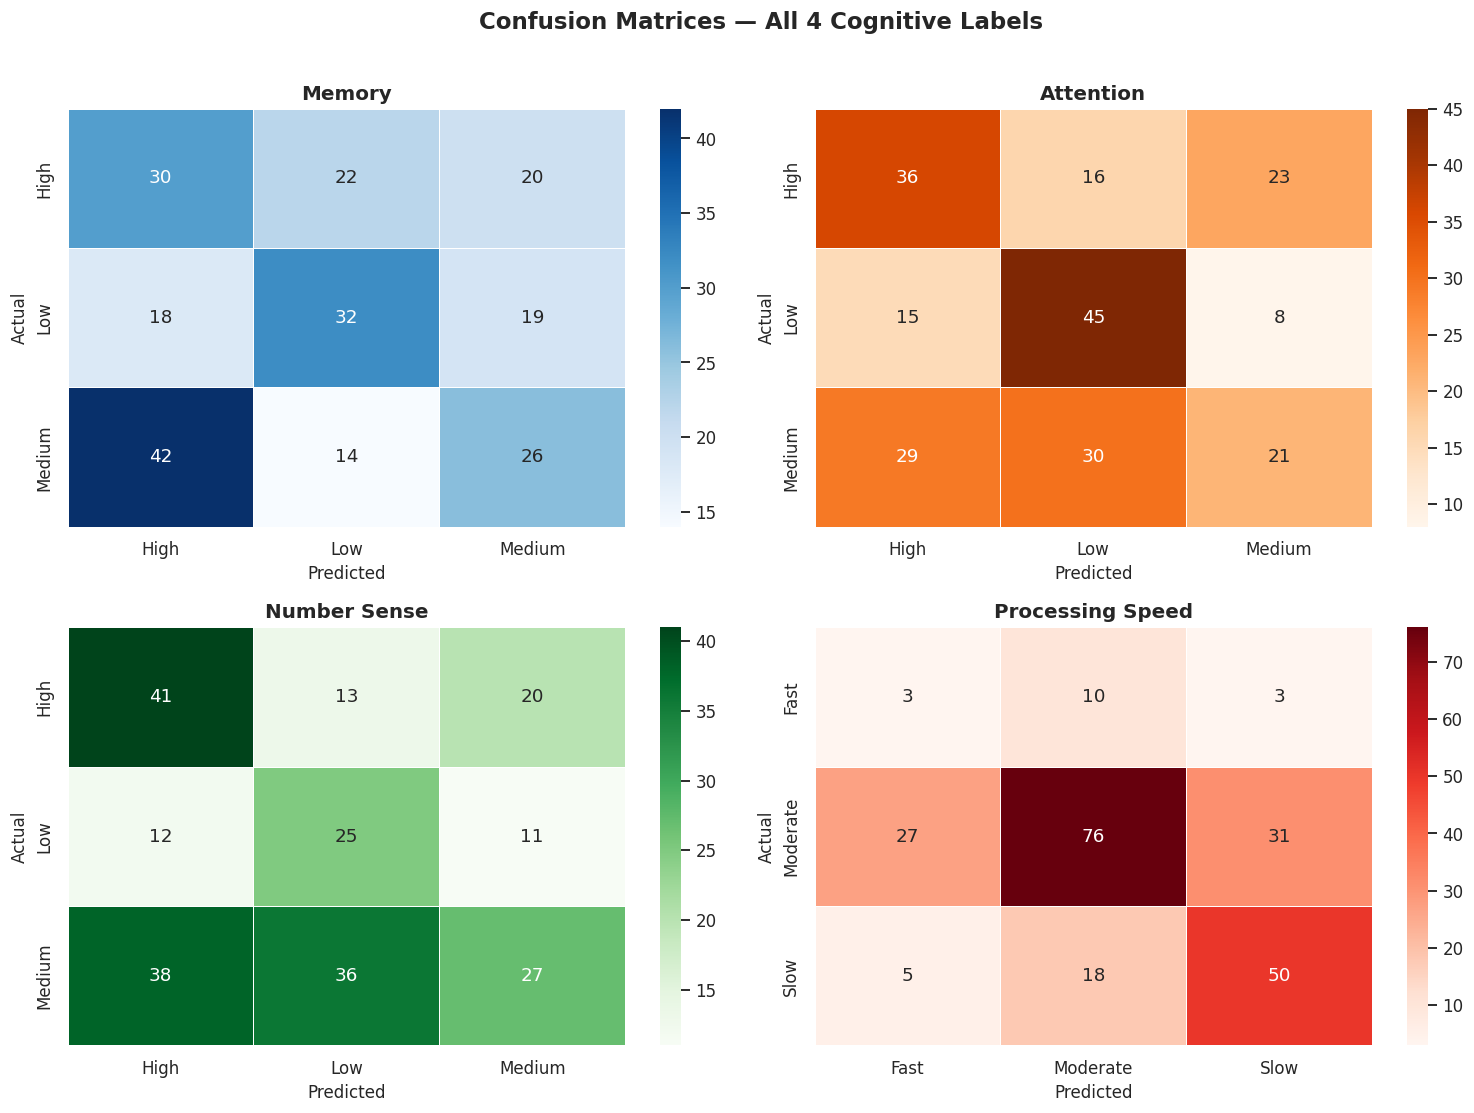

✅ Plot saved: confusion_matrices.png


In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cmap_list = ['Blues', 'Oranges', 'Greens', 'Reds']

for i, (target, cmap) in enumerate(zip(TARGET_COLS, cmap_list)):
    y_true_t = y_test[target].values
    y_pred_t = y_pred_df[target].values
    labels   = sorted(set(y_true_t) | set(y_pred_t))
    cm       = confusion_matrix(y_true_t, y_pred_t, labels=labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=axes[i], linewidths=0.5, linecolor='white',
                annot_kws={'size': 12})
    title = target.replace('label_', '').replace('_', ' ').title()
    axes[i].set_title(f'{title}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=11)
    axes[i].set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices — All 4 Cognitive Labels', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved: confusion_matrices.png")


## 1️⃣2️⃣ Feature Importance

Decision Trees compute **feature importances** — how much each feature contributed to reducing impurity (Gini) across all splits. A higher value means the feature was more useful in making predictions.


In [75]:
# ── Extract feature names after preprocessing ───────────────
preprocessor_fitted = model_pipeline.named_steps['preprocessor']

# Numerical feature names (unchanged)
num_names = numerical_features

# Categorical feature names (after OneHotEncoder)
cat_names = list(
    preprocessor_fitted
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features)
)

# Boolean feature names (unchanged)
bool_names = boolean_features

all_feature_names = num_names + cat_names + bool_names
print(f"Total features after preprocessing: {len(all_feature_names)}")


Total features after preprocessing: 39


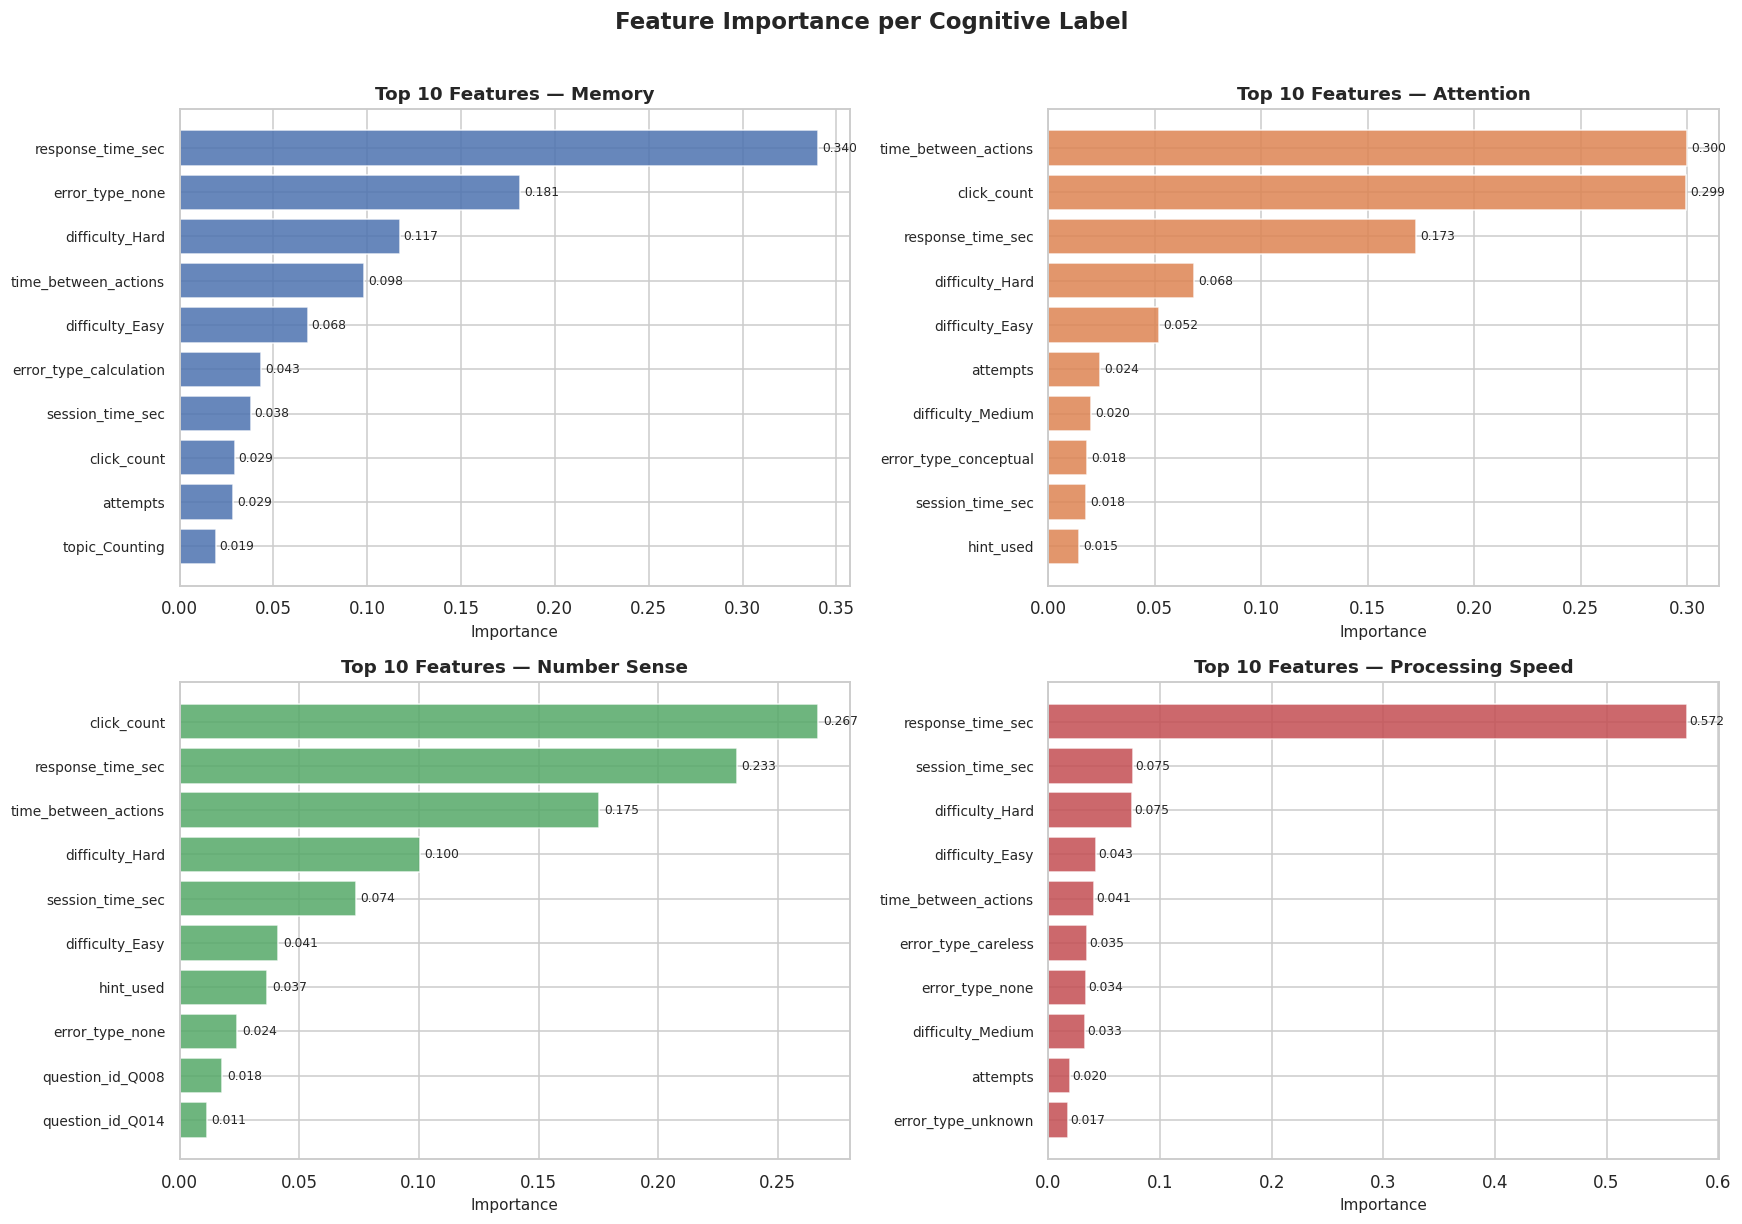

✅ Plot saved: feature_importance.png


In [76]:
# ── Plot top-10 feature importances for each target ─────────
estimators = model_pipeline.named_steps['classifier'].estimators_
colors_fi   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, (target, color) in enumerate(zip(TARGET_COLS, colors_fi)):
    importances = estimators[i].feature_importances_
    # Build series and sort
    fi_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
    top10     = fi_series.head(10).sort_values()

    axes[i].barh(top10.index, top10.values, color=color, alpha=0.85, edgecolor='white')
    title = target.replace('label_', '').replace('_', ' ').title()
    axes[i].set_title(f'Top 10 Features — {title}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Importance', fontsize=10)
    axes[i].tick_params(axis='y', labelsize=9)
    for patch, val in zip(axes[i].patches, top10.values):
        axes[i].text(val + 0.002, patch.get_y() + patch.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance per Cognitive Label', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved: feature_importance.png")


**Interpretation of Feature Importance:**
- **`response_time_sec`** and **`session_time_sec`** are typically strong predictors of *processing speed*.
- **`attempts`** and **`is_correct`** strongly influence *memory* and *number sense* predictions.
- **`hint_used`** and **`error_type`** contribute to *attention* and *memory* profiles.
- **`click_count`** reflects exploratory behaviour, useful for *attention* prediction.
- **`difficulty`** and **`topic`** contextualise the interaction for all four labels.


## 1️⃣3️⃣ Hyperparameter Tuning

We use `RandomizedSearchCV` to search for better hyperparameters. Because our dataset has grouped students, we use `GroupKFold` as the cross-validation strategy to **prevent student leakage during CV**.

> **Note:** `GridSearchCV` with multi-output classifiers can be slow. `RandomizedSearchCV` samples a fixed number of random parameter combinations, making it much faster for pilot datasets.


In [77]:
from sklearn.metrics import make_scorer
from scipy.stats import randint

# ── Custom scorer: average macro-F1 across all 4 targets ────
def avg_macro_f1(y_true, y_pred):
    scores = []
    for i in range(y_true.shape[1]):
        scores.append(f1_score(y_true[:, i], y_pred[:, i],
                               average='macro', zero_division=0))
    return np.mean(scores)

multi_f1_scorer = make_scorer(avg_macro_f1)

# ── Parameter search space ───────────────────────────────────
param_dist = {
    'classifier__estimator__max_depth'        : [4, 5, 6, 7, 8, None],
    'classifier__estimator__min_samples_split': randint(5, 20),
    'classifier__estimator__min_samples_leaf' : randint(3, 15),
    'classifier__estimator__criterion'        : ['gini', 'entropy'],
    'classifier__estimator__class_weight'     : ['balanced', None]
}

# ── GroupKFold CV (respects student groups) ──────────────────
gkf = GroupKFold(n_splits=4)

# ── RandomizedSearchCV ───────────────────────────────────────
rscv = RandomizedSearchCV(
    estimator  = model_pipeline,
    param_distributions = param_dist,
    n_iter     = 20,
    scoring    = multi_f1_scorer,
    cv         = gkf,
    refit      = True,
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1
)

print("Running RandomizedSearchCV (20 iterations × 4-fold GroupKFold)...")
rscv.fit(X_train, y_train, groups=groups_train)

print(f"\n✅ Tuning complete.")
print(f"   Best CV Score (avg macro-F1): {rscv.best_score_:.4f}")
print(f"   Best Parameters:")
for k, v in rscv.best_params_.items():
    print(f"     {k}: {v}")


Running RandomizedSearchCV (20 iterations × 4-fold GroupKFold)...
Fitting 4 folds for each of 20 candidates, totalling 80 fits

✅ Tuning complete.
   Best CV Score (avg macro-F1): nan
   Best Parameters:
     classifier__estimator__class_weight: balanced
     classifier__estimator__criterion: entropy
     classifier__estimator__max_depth: 8
     classifier__estimator__min_samples_leaf: 13
     classifier__estimator__min_samples_split: 12


## 1️⃣4️⃣ Train Final Best Model & Compare

In [78]:
# ── Use the best model from tuning ──────────────────────────
best_model = rscv.best_estimator_

# ── Evaluate best model on test set ─────────────────────────
y_pred_best = best_model.predict(X_test)
y_pred_best_df = pd.DataFrame(y_pred_best, columns=TARGET_COLS)

print("BEFORE TUNING vs AFTER TUNING")
print(f"{'Label':<25} {'Before F1':>12} {'After F1':>12}")
print("-" * 52)

before_f1_list = []
after_f1_list  = []

for i, target in enumerate(TARGET_COLS):
    f1_before = f1_score(y_test[target], y_pred_df[target],
                         average='macro', zero_division=0)
    f1_after  = f1_score(y_test[target], y_pred_best_df[target],
                         average='macro', zero_division=0)
    before_f1_list.append(f1_before)
    after_f1_list.append(f1_after)
    label = target.replace('label_', '').replace('_', ' ').title()
    marker = '✅' if f1_after >= f1_before else '⚠️ '
    print(f"  {label:<23} {f1_before:>12.4f} {f1_after:>12.4f}  {marker}")

print("-" * 52)
print(f"  {'Average':<23} {np.mean(before_f1_list):>12.4f} {np.mean(after_f1_list):>12.4f}")


BEFORE TUNING vs AFTER TUNING
Label                        Before F1     After F1
----------------------------------------------------
  Memory                        0.3971       0.3911  ⚠️ 
  Attention                     0.4496       0.4343  ⚠️ 
  Number Sense                  0.4155       0.4194  ✅
  Processing Speed              0.4644       0.4337  ⚠️ 
----------------------------------------------------
  Average                       0.4316       0.4196


## 1️⃣5️⃣ Overfitting Check

Comparing training score vs testing score helps diagnose overfitting or underfitting.

| Scenario | Interpretation |
|---|---|
| Training ≈ Testing (both high) | ✅ Good generalisation |
| Training >> Testing | ⚠️ Overfitting — model memorised training data |
| Training ≈ Testing (both low) | ❌ Underfitting — model too simple |


In [79]:
# ── Training predictions ────────────────────────────────────
y_train_pred = best_model.predict(X_train)
y_train_pred_df = pd.DataFrame(y_train_pred, columns=TARGET_COLS)

print(f"{'Label':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}  Diagnosis")
print("-" * 70)

for target in TARGET_COLS:
    train_acc = accuracy_score(y_train[target], y_train_pred_df[target])
    test_acc  = accuracy_score(y_test[target],  y_pred_best_df[target])
    gap       = train_acc - test_acc
    label = target.replace('label_', '').replace('_', ' ').title()
    if gap > 0.15:
        diag = "⚠️  Overfitting"
    elif test_acc < 0.50:
        diag = "❌ Underfitting"
    else:
        diag = "✅ Good fit"
    print(f"  {label:<23} {train_acc:>10.4f} {test_acc:>10.4f} {gap:>8.4f}  {diag}")


Label                      Train Acc   Test Acc      Gap  Diagnosis
----------------------------------------------------------------------
  Memory                      0.5708     0.3946   0.1762  ⚠️  Overfitting
  Attention                   0.5485     0.4395   0.1090  ❌ Underfitting
  Number Sense                0.5641     0.4215   0.1426  ❌ Underfitting
  Processing Speed            0.6421     0.5112   0.1309  ✅ Good fit


## 1️⃣6️⃣ Save the Model

In [80]:
MODEL_FILE = 'cognitive_model.pkl'

# ── Collect label classes for each target ───────────────────
label_classes = {}
for i, target in enumerate(TARGET_COLS):
    label_classes[target] = list(best_model.named_steps['classifier'].estimators_[i].classes_)

# ── Save artifact ────────────────────────────────────────────
artifact = {
    'model'         : best_model,
    'feature_cols'  : FEATURE_COLS,
    'target_cols'   : TARGET_COLS,
    'label_classes' : label_classes
}

joblib.dump(artifact, MODEL_FILE)
size_kb = os.path.getsize(MODEL_FILE) / 1024
print(f"✅ Model saved: {MODEL_FILE}  ({size_kb:.1f} KB)")
print(f"   Feature columns : {len(FEATURE_COLS)}")
print(f"   Target  columns : {TARGET_COLS}")
print(f"   Label classes   : {label_classes}")


✅ Model saved: cognitive_model.pkl  (41.7 KB)
   Feature columns : 11
   Target  columns : ['label_memory', 'label_attention', 'label_number_sense', 'label_processing_speed']
   Label classes   : {'label_memory': ['High', 'Low', 'Medium'], 'label_attention': ['High', 'Low', 'Medium'], 'label_number_sense': ['High', 'Low', 'Medium'], 'label_processing_speed': ['Fast', 'Moderate', 'Slow']}


## 1️⃣7️⃣ Load Saved Model and Test Prediction

In [81]:
# ── Load artifact ────────────────────────────────────────────
loaded_artifact = joblib.load(MODEL_FILE)
loaded_model    = loaded_artifact['model']
loaded_features = loaded_artifact['feature_cols']
loaded_targets  = loaded_artifact['target_cols']

print(f"✅ Model loaded from: {MODEL_FILE}")

# ── Prediction function ──────────────────────────────────────
def predict_cognitive_profile(sample_data: dict) -> dict:
    """
    Predict the cognitive profile for a single student interaction.

    Parameters
    ----------
    sample_data : dict
        Keys must match FEATURE_COLS.

    Returns
    -------
    dict
        Predicted levels for Memory, Attention, Number Sense, Processing Speed.
    """
    sample_df  = pd.DataFrame([sample_data])
    prediction = loaded_model.predict(sample_df)[0]

    label_map = {
        'label_memory'           : 'Memory',
        'label_attention'        : 'Attention',
        'label_number_sense'     : 'Number Sense',
        'label_processing_speed' : 'Processing Speed'
    }

    profile = {}
    for i, target in enumerate(loaded_targets):
        profile[label_map[target]] = prediction[i]
    return profile

# ── Sample input (manual) ────────────────────────────────────
sample_input = {
    'question_id'          : 'Q005',
    'topic'                : 'Addition',
    'difficulty'           : 'Medium',
    'response_time_sec'    : 28.5,
    'attempts'             : 3,
    'is_correct'           : 0,          # 0 = False
    'hint_used'            : 1,          # 1 = True
    'click_count'          : 9,
    'session_time_sec'     : 180.0,
    'time_between_actions' : 2.8,
    'error_type'           : 'conceptual'
}

result = predict_cognitive_profile(sample_input)
print("\n── Cognitive Profile Prediction ──")
for dim, level in result.items():
    print(f"   {dim:<20}: {level}")


✅ Model loaded from: cognitive_model.pkl

── Cognitive Profile Prediction ──
   Memory              : Low
   Attention           : Low
   Number Sense        : Low
   Processing Speed    : Slow


## 1️⃣8️⃣ Student-Level Aggregation (Majority Voting)

Each row is **one question interaction**. The model predicts a label per interaction. For a student's **final cognitive profile**, we aggregate predictions across all their interactions using **majority voting** — the most common prediction for each label becomes the student's profile.


In [82]:
from scipy.stats import mode as scipy_mode

def get_student_profile(student_id: str, df_all: pd.DataFrame,
                        model, feature_cols: list, target_cols: list) -> dict:
    """Predict and aggregate cognitive profile for a single student via majority vote."""
    student_rows = df_all[df_all['student_id'] == student_id][feature_cols]
    if student_rows.empty:
        return {'Error': f'Student {student_id} not found'}

    preds = model.predict(student_rows)
    preds_df = pd.DataFrame(preds, columns=target_cols)

    label_map = {
        'label_memory'           : 'Memory',
        'label_attention'        : 'Attention',
        'label_number_sense'     : 'Number Sense',
        'label_processing_speed' : 'Processing Speed'
    }

    profile = {'student_id': student_id}
    for target in target_cols:
        votes   = preds_df[target].values
        # majority vote
        winner  = pd.Series(votes).value_counts().idxmax()
        profile[label_map[target]] = winner
    return profile

# ── Demo: predict profiles for a sample of 3 students ────────
sample_students = ['S001', 'S005', 'S015']
print("Student-Level Cognitive Profiles (Majority Vote):")
print("=" * 55)
for sid in sample_students:
    if sid in df['student_id'].values:
        prof = get_student_profile(sid, df, loaded_model,
                                   loaded_features, loaded_targets)
        print(f"\n  Student: {sid}")
        for k, v in prof.items():
            if k != 'student_id':
                print(f"    {k:<20}: {v}")


Student-Level Cognitive Profiles (Majority Vote):

  Student: S001
    Memory              : High
    Attention           : High
    Number Sense        : High
    Processing Speed    : Fast

  Student: S005
    Memory              : Low
    Attention           : Low
    Number Sense        : Low
    Processing Speed    : Slow

  Student: S015
    Memory              : High
    Attention           : High
    Number Sense        : High
    Processing Speed    : Moderate


## 1️⃣9️⃣ Export Student Profile Predictions to CSV

In [83]:
OUTPUT_CSV = 'mathsmate_student_cognitive_profile_predictions.csv'

all_student_ids = df['student_id'].unique()
profiles = []

for sid in all_student_ids:
    prof = get_student_profile(sid, df, loaded_model, loaded_features, loaded_targets)
    profiles.append({
        'student_id'             : sid,
        'predicted_memory'       : prof.get('Memory', 'N/A'),
        'predicted_attention'    : prof.get('Attention', 'N/A'),
        'predicted_number_sense' : prof.get('Number Sense', 'N/A'),
        'predicted_processing_speed': prof.get('Processing Speed', 'N/A')
    })

profile_df = pd.DataFrame(profiles)
profile_df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Student profiles exported: {OUTPUT_CSV}")
print(f"   Total students: {len(profile_df)}")
print()
print(profile_df.head(10).to_string(index=False))


✅ Student profiles exported: mathsmate_student_cognitive_profile_predictions.csv
   Total students: 63

student_id predicted_memory predicted_attention predicted_number_sense predicted_processing_speed
      S001             High                High                   High                       Fast
      S002             High                High                   High                       Fast
      S003           Medium                 Low                    Low                       Slow
      S004              Low                 Low                    Low                       Slow
      S005              Low                 Low                    Low                       Slow
      S006           Medium                 Low                 Medium                       Slow
      S007             High                High                 Medium                   Moderate
      S008              Low                 Low                    Low                       Slow
      S009    

## 2️⃣0️⃣ Model Limitations

1. **Small dataset** — 63 students, ~1 120 interactions. Conclusions are indicative, not statistically definitive.
2. **Synthetic / proxy labels** — The cognitive labels were assigned using heuristic rules based on interaction patterns, not validated by clinical assessment. They are **not clinical diagnoses**.
3. **Decision Tree limitations** — Although interpretable, single Decision Trees can **overfit** to training data even with depth constraints. Ensemble methods (Random Forest, XGBoost) would likely perform better.
4. **No temporal modelling** — Each interaction is treated independently. **Student progress over time** (learning curves) is not captured.
5. **Cognitive labels need expert validation** — Labels should be reviewed by teachers, educational psychologists, or domain experts before deployment.
6. **Dyscalculia screening requires clinical tools** — This model provides **educational insight only**, not a diagnostic tool. Students requiring special educational needs assessment should be referred to qualified professionals.
7. **Generalisation** — Results may not generalise beyond the 63-student pilot cohort without more diverse data.


## 2️⃣1️⃣ Future Improvements

| Direction | Detail |
|---|---|
| 🌲 **Random Forest** | Ensemble of trees — reduces overfitting significantly |
| ⚡ **XGBoost / LightGBM** | Gradient boosting — typically best performance on tabular data |
| 🧠 **Neural Network** | Can capture non-linear feature interactions at scale |
| 📈 **More real data** | Collect data from hundreds of students across schools |
| ⏱️ **Time-series modelling** | Track student progress longitudinally (session-by-session) |
| 🔄 **Adaptive recommendations** | Feed cognitive profiles into a recommendation engine |
| 📊 **Teacher dashboard** | Visual dashboard showing class-wide cognitive profiles |
| 🔍 **Explainable AI (XAI)** | SHAP / LIME explanations for individual predictions |
| 🏷️ **Expert label validation** | Clinical co-labelling by educational psychologists |
| 📱 **Student-level time-series** | Sequence models (LSTM, Transformer) per student |


## 2️⃣2️⃣ How to Explain This Model in a Viva

---

### 🎤 Simple Explanation

> *"This model takes student interaction data — such as response time, number of attempts, correctness, hint usage, click count, and error type — and uses these behavioural patterns to predict four cognitive skill labels: memory, attention, number sense, and processing speed. Because we predict more than one label at the same time, this is a **multi-output classification** problem. I used a **Decision Tree** because it is simple, interpretable, and suitable for explaining the decision-making process in an educational research context. I used **grouped train-test splitting** by student ID to prevent data leakage, ensuring that no student's records appear in both training and testing sets."*

---

### ❓ Viva Questions and Answers

**Q: Why is this multi-output classification?**
> Because we predict **four target labels simultaneously** — memory, attention, number sense, and processing speed. Each label is a categorical class (Low/Medium/High or Slow/Moderate/Fast). Predicting multiple categorical labels at once defines multi-output classification.

**Q: Why did you use Decision Tree?**
> Decision Trees are interpretable — we can trace exactly how a prediction was made by following the decision path. For educational research, transparency is important because teachers and researchers need to understand *why* a student is predicted to have Low memory, for example. Decision Trees also handle mixed feature types (categorical + numerical) naturally.

**Q: Why not use `student_id` as a feature?**
> Using `student_id` would cause the model to **memorise** each student's answers instead of learning generalizable patterns. On a new student the model has never seen, it would have no meaningful prediction. This is called **data leakage**.

**Q: What is data leakage?**
> Data leakage happens when information from the test set (or future data) is used during training, making the model appear more accurate than it actually is. In this dataset, each student appears in multiple rows. A random split could place the same student in both train and test, letting the model "see" that student's pattern during training — this is leakage.

**Q: Why grouped split?**
> `GroupShuffleSplit` with `student_id` as groups guarantees that **all rows of a student go entirely into train OR entirely into test**. This simulates the real-world scenario where the model must predict for a completely new student it has never encountered.

**Q: What are the input features?**
> `question_id`, `topic`, `difficulty`, `response_time_sec`, `attempts`, `is_correct`, `hint_used`, `click_count`, `session_time_sec`, `time_between_actions`, `error_type`.

**Q: What are the target labels?**
> `label_memory` (Low/Medium/High), `label_attention` (Low/Medium/High), `label_number_sense` (Low/Medium/High), `label_processing_speed` (Slow/Moderate/Fast).

**Q: How do you evaluate the model?**
> Per-label: accuracy, precision (macro), recall (macro), F1-score (macro), and confusion matrix. Multi-output: exact match accuracy and Hamming loss.

**Q: What is exact match accuracy?**
> The percentage of test rows where **all four labels** were predicted correctly at the same time. It is a strict metric — even one wrong label makes the row incorrect.

**Q: What is Hamming loss?**
> The fraction of individual labels that were predicted incorrectly across all rows and all targets. Lower is better. A Hamming loss of 0.2 means 20% of all label predictions were wrong.

**Q: How do you avoid overfitting?**
> By setting `max_depth`, `min_samples_split`, and `min_samples_leaf` in the Decision Tree. These hyperparameters prevent the tree from growing too deep and memorising noise in the training data. I also use `class_weight='balanced'` to handle class imbalance fairly.

**Q: What are the limitations?**
> Small pilot dataset, synthetic labels not validated by clinical experts, Decision Trees can still overfit, no temporal modelling of student progress, and the model provides educational insight — not a clinical diagnosis.

**Q: How can this model be improved?**
> By collecting more real student data, using Random Forest or XGBoost instead of a single Decision Tree, validating labels with educational psychologists, and adding a longitudinal tracking component that monitors progress over time.

---

*Good luck with your viva! 🎓*
